In [7]:
!pip install -q open_clip_torch

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from pathlib import Path
import copy
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import STL10
from torchvision.transforms import functional as TF
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    vit_b_16,
    ViT_B_16_Weights,
)

import open_clip

from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

In [9]:
PROJECT_ROOT = Path("/content/drive/MyDrive/ATML/PA1")
TASK1_ROOT = PROJECT_ROOT / "task1"

DATA_ROOT = PROJECT_ROOT / "datasets"
SPLITS_DIR = TASK1_ROOT / "splits"
FEATURES_DIR = TASK1_ROOT / "cached_features"
CHECKPOINTS_DIR = TASK1_ROOT / "checkpoints"
RESULTS_DIR = TASK1_ROOT / "results"
FIGURES_DIR = TASK1_ROOT / "figures"

SEED = 6304
IMAGE_SIZE = 224
NUM_CLASSES = 10
FEATURE_BATCH_SIZE = 64

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CLASS_NAMES = [
    "airplane",
    "bird",
    "car",
    "cat",
    "deer",
    "dog",
    "horse",
    "monkey",
    "ship",
    "truck",
]

print("Device:", DEVICE)

Device: cuda


In [10]:
def set_seed(seed=6304):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [11]:
#loading the same test images

test_dataset_raw = STL10(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=None,
)

TEST_SUBSET_PATH = (
    SPLITS_DIR / "stl10_test_subset_500_seed6304.json"
)

with open(TEST_SUBSET_PATH, "r") as file:
    saved_test_subset = json.load(file)

test_indices = np.array(
    saved_test_subset["test_indices"]
)

print("Selected test images:", len(test_indices))
print("Unique images:", len(np.unique(test_indices)))

Selected test images: 500
Unique images: 500


In [12]:
#preprocessing

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

CLIP_MEAN = (
    0.48145466,
    0.45782750,
    0.40821073,
)

CLIP_STD = (
    0.26862954,
    0.26130258,
    0.27577711,
)

common_resize = transforms.Resize(
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=transforms.InterpolationMode.BICUBIC,
    antialias=True,
)


def get_normalization(model_name):
    if model_name in ["resnet50", "vit_b_16"]:
        return transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        )

    if model_name == "clip_vit_b_32":
        return transforms.Normalize(
            mean=CLIP_MEAN,
            std=CLIP_STD,
        )

    raise ValueError(f"Unknown model: {model_name}")

In [13]:
#grayscale and hue rotation

def apply_grayscale(image, image_index=None):
    return TF.rgb_to_grayscale(
        image,
        num_output_channels=3,
    )


def apply_hue_rotation(image, image_index=None):
    return TF.adjust_hue(
        image,
        hue_factor=0.25,
    )

In [14]:
#translation

def translate_with_reflection(
    image,
    displacement,
    direction,
):
    if displacement == 0:
        return image

    padded = TF.pad(
        image,
        padding=[
            displacement,
            displacement,
            displacement,
            displacement,
        ],
        padding_mode="reflect",
    )

    if direction == "right":
        left = 0
        top = displacement

    elif direction == "left":
        left = 2 * displacement
        top = displacement

    elif direction == "down":
        left = displacement
        top = 0

    elif direction == "up":
        left = displacement
        top = 2 * displacement

    else:
        raise ValueError(
            f"Unknown translation direction: {direction}"
        )

    return TF.crop(
        padded,
        top=top,
        left=left,
        height=IMAGE_SIZE,
        width=IMAGE_SIZE,
    )


def make_translation(displacement, direction):
    def intervention(image, image_index=None):
        return translate_with_reflection(
            image,
            displacement=displacement,
            direction=direction,
        )

    return intervention

In [15]:
#patch permutations

PATCH_GRID_SIZE = 4
NUMBER_OF_PATCHES = PATCH_GRID_SIZE ** 2

PATCH_PERMUTATION_PATH = (
    SPLITS_DIR / "patch_permutations_4x4_seed6304.json"
)

identity_permutation = np.arange(NUMBER_OF_PATCHES)

if PATCH_PERMUTATION_PATH.exists():
    with open(PATCH_PERMUTATION_PATH, "r") as file:
        saved_permutations = json.load(file)

    patch_permutations = {
        int(index): permutation
        for index, permutation in saved_permutations.items()
    }

    print("Loaded existing patch permutations.")

else:
    rng = np.random.default_rng(SEED)
    patch_permutations = {}

    for image_index in test_indices:
        permutation = rng.permutation(
            NUMBER_OF_PATCHES
        )

        while np.array_equal(
            permutation,
            identity_permutation,
        ):
            permutation = rng.permutation(
                NUMBER_OF_PATCHES
            )

        patch_permutations[int(image_index)] = (
            permutation.tolist()
        )

    with open(PATCH_PERMUTATION_PATH, "w") as file:
        json.dump(
            {
                str(index): permutation
                for index, permutation
                in patch_permutations.items()
            },
            file,
            indent=2,
        )

    print("Created and saved patch permutations.")

print("Number of saved permutations:", len(patch_permutations))

Loaded existing patch permutations.
Number of saved permutations: 500


In [16]:
#patch shuffling

def apply_patch_shuffle(image, image_index):
    image_tensor = TF.pil_to_tensor(image)

    channels, height, width = image_tensor.shape

    assert height % PATCH_GRID_SIZE == 0
    assert width % PATCH_GRID_SIZE == 0

    patch_height = height // PATCH_GRID_SIZE
    patch_width = width // PATCH_GRID_SIZE

    patches = image_tensor.reshape(
        channels,
        PATCH_GRID_SIZE,
        patch_height,
        PATCH_GRID_SIZE,
        patch_width,
    )

    patches = patches.permute(
        1, 3, 0, 2, 4
    ).reshape(
        NUMBER_OF_PATCHES,
        channels,
        patch_height,
        patch_width,
    )

    permutation = torch.tensor(
        patch_permutations[int(image_index)],
        dtype=torch.long,
    )

    shuffled_patches = patches[permutation]

    shuffled_image = shuffled_patches.reshape(
        PATCH_GRID_SIZE,
        PATCH_GRID_SIZE,
        channels,
        patch_height,
        patch_width,
    )

    shuffled_image = shuffled_image.permute(
        2, 0, 3, 1, 4
    ).reshape(
        channels,
        height,
        width,
    )

    return TF.to_pil_image(shuffled_image)

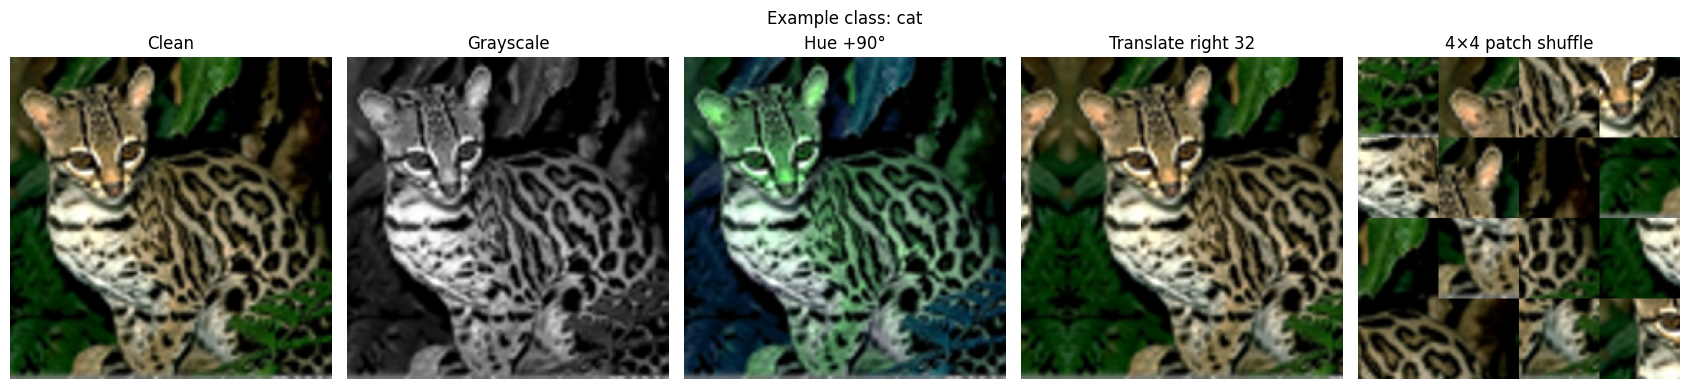

In [17]:
example_index = int(test_indices[0])

example_image, example_label = (
    test_dataset_raw[example_index]
)

example_image = common_resize(
    example_image.convert("RGB")
)

example_images = [
    ("Clean", example_image),
    ("Grayscale", apply_grayscale(example_image)),
    ("Hue +90°", apply_hue_rotation(example_image)),
    (
        "Translate right 32",
        translate_with_reflection(
            example_image,
            displacement=32,
            direction="right",
        ),
    ),
    (
        "4×4 patch shuffle",
        apply_patch_shuffle(
            example_image,
            example_index,
        ),
    ),
]

fig, axes = plt.subplots(
    1,
    len(example_images),
    figsize=(17, 4),
)

for axis, (title, image) in zip(
    axes,
    example_images,
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

plt.suptitle(
    f"Example class: {CLASS_NAMES[example_label]}"
)

plt.tight_layout()
plt.show()

In [18]:
class InterventionDataset(Dataset):
    def __init__(
        self,
        base_dataset,
        indices,
        model_name,
        intervention=None,
    ):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.normalization = get_normalization(
            model_name
        )
        self.intervention = intervention

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        image_index = int(self.indices[position])

        image, label = self.base_dataset[image_index]

        image = image.convert("RGB")
        image = common_resize(image)

        if self.intervention is not None:
            image = self.intervention(
                image,
                image_index,
            )

        image = TF.to_tensor(image)
        image = self.normalization(image)

        return image, int(label), image_index

In [19]:
def make_intervention_loader(
    model_name,
    intervention=None,
):
    dataset = InterventionDataset(
        base_dataset=test_dataset_raw,
        indices=test_indices,
        model_name=model_name,
        intervention=intervention,
    )

    return DataLoader(
        dataset,
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

In [20]:
class FrozenBackbone(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.model_name = model_name

        if model_name == "resnet50":
            model = resnet50(
                weights=ResNet50_Weights.IMAGENET1K_V2
            )

            model.fc = nn.Identity()

            self.feature_dim = 2048

        elif model_name == "vit_b_16":
            model = vit_b_16(
                weights=ViT_B_16_Weights.IMAGENET1K_V1
            )

            model.heads = nn.Identity()

            self.feature_dim = 768

        elif model_name == "clip_vit_b_32":
            model, _, _ = (
                open_clip.create_model_and_transforms(
                    model_name="ViT-B-32-quickgelu",
                    pretrained="openai",
                )
            )

            self.feature_dim = model.visual.output_dim

        else:
            raise ValueError(
                f"Unknown model: {model_name}"
            )

        self.model = model

        for parameter in self.model.parameters():
            parameter.requires_grad = False

        self.model.eval()

    def forward(self, images):
        if self.model_name == "clip_vit_b_32":
            features = self.model.encode_image(images)
            features = F.normalize(features, dim=1)
            return features

        return self.model(images)

In [21]:
#loading trained linear head

def load_linear_head(model_name):
    checkpoint_path = (
        CHECKPOINTS_DIR
        / f"{model_name}_linear_head.pt"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    head = nn.Linear(
        checkpoint["feature_dim"],
        checkpoint["number_of_classes"],
    ).to(DEVICE)

    head.load_state_dict(
        checkpoint["state_dict"]
    )

    head.eval()

    return head

In [22]:
@torch.inference_mode()
def extract_features(
    backbone,
    loader,
    description,
):
    backbone.eval()

    all_features = []
    all_labels = []
    all_indices = []

    for images, labels, indices in tqdm(
        loader,
        desc=description,
    ):
        images = images.to(DEVICE)

        features = backbone(images)

        all_features.append(
            features.float().cpu()
        )
        all_labels.append(labels.cpu())
        all_indices.append(indices.cpu())

    return {
        "features": torch.cat(
            all_features,
            dim=0,
        ),
        "labels": torch.cat(
            all_labels,
            dim=0,
        ),
        "indices": torch.cat(
            all_indices,
            dim=0,
        ),
    }


def get_or_extract_features(
    backbone,
    model_name,
    condition_name,
    intervention,
):
    feature_path = (
        FEATURES_DIR
        / f"{model_name}_{condition_name}_test.pt"
    )

    if feature_path.exists():
        print("Loading:", feature_path.name)

        return torch.load(
            feature_path,
            map_location="cpu",
            weights_only=False,
        )

    loader = make_intervention_loader(
        model_name=model_name,
        intervention=intervention,
    )

    data = extract_features(
        backbone,
        loader,
        description=f"{model_name}: {condition_name}",
    )

    torch.save(data, feature_path)

    return data

In [23]:
@torch.inference_mode()
def prepare_clip_zero_shot(backbone):
    tokenizer = open_clip.get_tokenizer(
        "ViT-B-32-quickgelu"
    )

    prompts = [
        f"a photo of a {class_name}."
        for class_name in CLASS_NAMES
    ]

    tokens = tokenizer(prompts).to(DEVICE)

    text_features = backbone.model.encode_text(tokens)
    text_features = F.normalize(
        text_features,
        dim=1,
    )

    logit_scale = backbone.model.logit_scale.exp()

    return text_features, logit_scale

In [24]:
@torch.inference_mode()
def predict_from_features(
    feature_data,
    evaluation_type,
    linear_head=None,
    text_features=None,
    logit_scale=None,
):
    features = feature_data["features"].to(DEVICE)
    labels = feature_data["labels"].to(DEVICE)

    if evaluation_type == "linear_head":
        logits = linear_head(features)

    elif evaluation_type == "zero_shot":
        logits = (
            logit_scale
            * features
            @ text_features.T
        )

    else:
        raise ValueError(
            f"Unknown evaluation type: {evaluation_type}"
        )

    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1)
    confidence = probabilities.max(dim=1).values

    return {
        "labels": labels.cpu(),
        "predictions": predictions.cpu(),
        "probabilities": probabilities.cpu(),
        "mean_max_confidence": (
            confidence.mean().item()
        ),
    }


def calculate_intervention_metrics(
    output,
    clean_output,
):
    labels = output["labels"].numpy()
    predictions = output["predictions"].numpy()

    clean_predictions = (
        clean_output["predictions"].numpy()
    )

    accuracy = accuracy_score(
        labels,
        predictions,
    )

    clean_accuracy = accuracy_score(
        clean_output["labels"].numpy(),
        clean_predictions,
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
    )

    consistency = np.mean(
        predictions == clean_predictions
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "mean_max_confidence": (
            output["mean_max_confidence"]
        ),
        "accuracy_change": (
            accuracy - clean_accuracy
        ),
        "prediction_consistency": consistency,
    }

In [25]:
MAIN_INTERVENTIONS = {
    "grayscale": apply_grayscale,
    "hue_rotation_90": apply_hue_rotation,
    "patch_shuffle_4x4": apply_patch_shuffle,
}

TRANSLATION_DISPLACEMENTS = [0, 8, 16, 32]

TRANSLATION_DIRECTIONS = [
    "up",
    "down",
    "left",
    "right",
]

MODEL_NAMES = [
    "resnet50",
    "vit_b_16",
    "clip_vit_b_32",
]

In [26]:
intervention_results = []
translation_directional_results = []

for model_name in MODEL_NAMES:
    print("\n" + "=" * 70)
    print("Processing:", model_name)
    print("=" * 70)

    backbone = FrozenBackbone(
        model_name
    ).to(DEVICE)

    linear_head = load_linear_head(
        model_name
    )

    evaluation_types = ["linear_head"]

    text_features = None
    logit_scale = None

    if model_name == "clip_vit_b_32":
        evaluation_types.append("zero_shot")

        text_features, logit_scale = (
            prepare_clip_zero_shot(backbone)
        )

    clean_data = torch.load(
        FEATURES_DIR
        / f"{model_name}_clean_test.pt",
        map_location="cpu",
        weights_only=False,
    )

    expected_indices = torch.tensor(
        test_indices,
        dtype=torch.long,
    )

    assert torch.equal(
        clean_data["indices"],
        expected_indices,
    )

    clean_outputs = {}

    for evaluation_type in evaluation_types:
        clean_output = predict_from_features(
            clean_data,
            evaluation_type=evaluation_type,
            linear_head=linear_head,
            text_features=text_features,
            logit_scale=logit_scale,
        )

        clean_outputs[evaluation_type] = clean_output

        clean_metrics = (
            calculate_intervention_metrics(
                clean_output,
                clean_output,
            )
        )

        intervention_results.append({
            "model": model_name,
            "evaluation": evaluation_type,
            "condition": "clean",
            **clean_metrics,
        })

    # Grayscale, hue rotation and patch shuffle
    for condition_name, intervention in (
        MAIN_INTERVENTIONS.items()
    ):
        transformed_data = get_or_extract_features(
            backbone=backbone,
            model_name=model_name,
            condition_name=condition_name,
            intervention=intervention,
        )

        assert torch.equal(
            transformed_data["indices"],
            clean_data["indices"],
        )

        for evaluation_type in evaluation_types:
            transformed_output = (
                predict_from_features(
                    transformed_data,
                    evaluation_type=evaluation_type,
                    linear_head=linear_head,
                    text_features=text_features,
                    logit_scale=logit_scale,
                )
            )

            metrics = calculate_intervention_metrics(
                transformed_output,
                clean_outputs[evaluation_type],
            )

            intervention_results.append({
                "model": model_name,
                "evaluation": evaluation_type,
                "condition": condition_name,
                **metrics,
            })

    # Translation experiment
    for displacement in TRANSLATION_DISPLACEMENTS:
        for direction in TRANSLATION_DIRECTIONS:

            if displacement == 0:
                translated_data = clean_data

            else:
                condition_name = (
                    f"translation_{direction}_"
                    f"{displacement}px"
                )

                translated_data = (
                    get_or_extract_features(
                        backbone=backbone,
                        model_name=model_name,
                        condition_name=condition_name,
                        intervention=make_translation(
                            displacement,
                            direction,
                        ),
                    )
                )

            assert torch.equal(
                translated_data["indices"],
                clean_data["indices"],
            )

            for evaluation_type in evaluation_types:
                translated_output = (
                    predict_from_features(
                        translated_data,
                        evaluation_type=evaluation_type,
                        linear_head=linear_head,
                        text_features=text_features,
                        logit_scale=logit_scale,
                    )
                )

                metrics = (
                    calculate_intervention_metrics(
                        translated_output,
                        clean_outputs[evaluation_type],
                    )
                )

                translation_directional_results.append({
                    "model": model_name,
                    "evaluation": evaluation_type,
                    "displacement": displacement,
                    "direction": direction,
                    **metrics,
                })

    del backbone
    del linear_head

    torch.cuda.empty_cache()


Processing: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 65.5MB/s]


resnet50: grayscale:   0%|          | 0/8 [00:00<?, ?it/s]

resnet50: hue_rotation_90:   0%|          | 0/8 [00:00<?, ?it/s]

resnet50: patch_shuffle_4x4:   0%|          | 0/8 [00:00<?, ?it/s]

...

clip_vit_b_32: translation_right_16px:   0%|          | 0/8 [00:00<?, ?it/s]

clip_vit_b_32: translation_up_32px:   0%|          | 0/8 [00:00<?, ?it/s]

clip_vit_b_32: translation_down_32px:   0%|          | 0/8 [00:00<?, ?it/s]

clip_vit_b_32: translation_left_32px:   0%|          | 0/8 [00:00<?, ?it/s]

clip_vit_b_32: translation_right_32px:   0%|          | 0/8 [00:00<?, ?it/s]

In [27]:
intervention_results_df = pd.DataFrame(
    intervention_results
)

intervention_results_df.to_csv(
    RESULTS_DIR / "color_patch_results.csv",
    index=False,
)

display(
    intervention_results_df.round(4)
)

,model,evaluation,condition,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,resnet50,linear_head,clean,0.976,0.9761,0.8978,0.000,1.000
1,resnet50,linear_head,grayscale,0.958,0.9578,0.9038,-0.018,0.964
2,resnet50,linear_head,hue_rotation_90,0.928,0.9278,0.8877,-0.048,0.940
3,resnet50,linear_head,patch_shuffle_4x4,0.876,0.8768,0.8711,-0.100,0.900
4,vit_b_16,linear_head,clean,0.974,0.9739,0.9590,0.000,1.000
5,vit_b_16,linear_head,grayscale,0.954,0.9539,0.9534,-0.020,0.950
6,vit_b_16,linear_head,hue_rotation_90,0.944,0.9440,0.9275,-0.030,0.944
7,vit_b_16,linear_head,patch_shuffle_4x4,0.906,0.9064,0.8844,-0.068,0.918
8,clip_vit_b_32,linear_head,clean,0.984,0.9840,0.3050,0.000,1.000
9,clip_vit_b_32,zero_shot,clean,0.980,0.9799,0.9548,0.000,1.000


In [28]:
translation_directional_df = pd.DataFrame(
    translation_directional_results
)

translation_average_df = (
    translation_directional_df
    .groupby(
        [
            "model",
            "evaluation",
            "displacement",
        ],
        as_index=False,
    )
    [
        [
            "accuracy",
            "macro_f1",
            "mean_max_confidence",
            "accuracy_change",
            "prediction_consistency",
        ]
    ]
    .mean()
)

translation_directional_df.to_csv(
    RESULTS_DIR / "translation_directional_results.csv",
    index=False,
)

translation_average_df.to_csv(
    RESULTS_DIR / "translation_average_results.csv",
    index=False,
)

display(
    translation_average_df.round(4)
)

,model,evaluation,displacement,accuracy,macro_f1,mean_max_confidence,accuracy_change,prediction_consistency
0,clip_vit_b_32,linear_head,0,0.9840,0.9840,0.3050,0.0000,1.0000
1,clip_vit_b_32,linear_head,8,0.9840,0.9840,0.3029,0.0000,0.9920
2,clip_vit_b_32,linear_head,16,0.9790,0.9790,0.2986,-0.0050,0.9860
3,clip_vit_b_32,linear_head,32,0.9745,0.9745,0.2932,-0.0095,0.9875
4,clip_vit_b_32,zero_shot,0,0.9800,0.9799,0.9548,0.0000,1.0000
5,clip_vit_b_32,zero_shot,8,0.9780,0.9779,0.9516,-0.0020,0.9865
6,clip_vit_b_32,zero_shot,16,0.9770,0.9768,0.9496,-0.0030,0.9830
7,clip_vit_b_32,zero_shot,32,0.9665,0.9664,0.9415,-0.0135,0.9825
8,resnet50,linear_head,0,0.9760,0.9761,0.8978,0.0000,1.0000
9,resnet50,linear_head,8,0.9705,0.9705,0.8965,-0.0055,0.9925


In [29]:
def make_system_name(row):
    if (
        row["model"] == "clip_vit_b_32"
        and row["evaluation"] == "zero_shot"
    ):
        return "CLIP zero-shot"

    if row["model"] == "clip_vit_b_32":
        return "CLIP linear head"

    if row["model"] == "vit_b_16":
        return "ViT-B/16"

    return "ResNet-50"


intervention_results_df["system"] = (
    intervention_results_df.apply(
        make_system_name,
        axis=1,
    )
)

translation_average_df["system"] = (
    translation_average_df.apply(
        make_system_name,
        axis=1,
    )
)

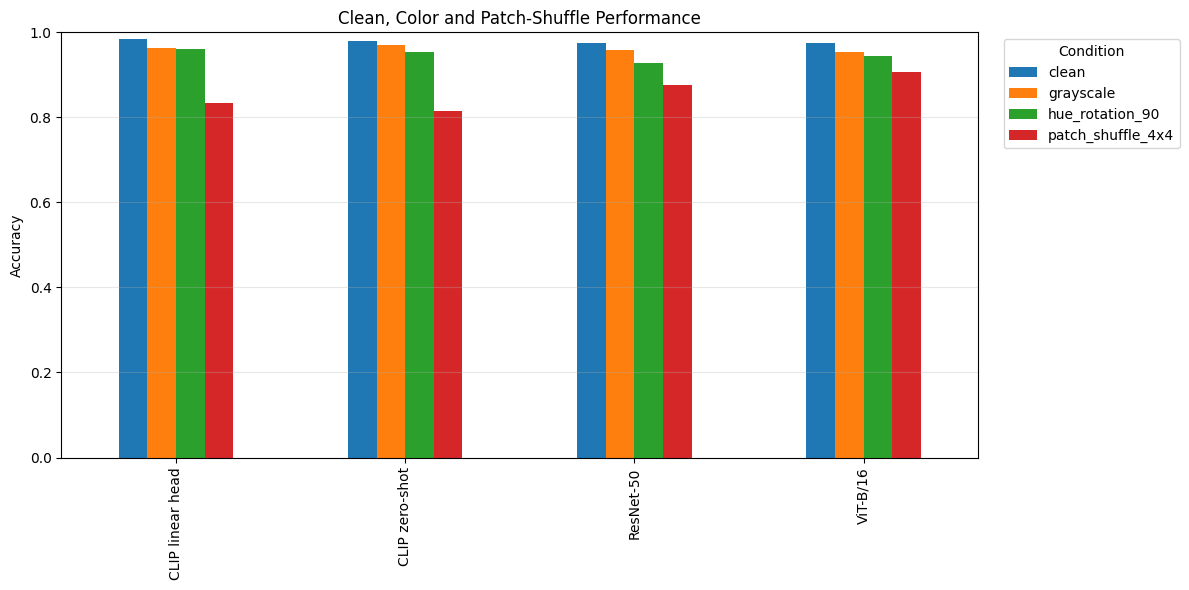

In [30]:
condition_order = [
    "clean",
    "grayscale",
    "hue_rotation_90",
    "patch_shuffle_4x4",
]

accuracy_pivot = (
    intervention_results_df
    .pivot(
        index="system",
        columns="condition",
        values="accuracy",
    )
    [condition_order]
)

accuracy_pivot.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.ylabel("Accuracy")
plt.xlabel("")
plt.title(
    "Clean, Color and Patch-Shuffle Performance"
)

plt.ylim(0, 1)
plt.grid(
    axis="y",
    alpha=0.3,
)

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "color_patch_accuracy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

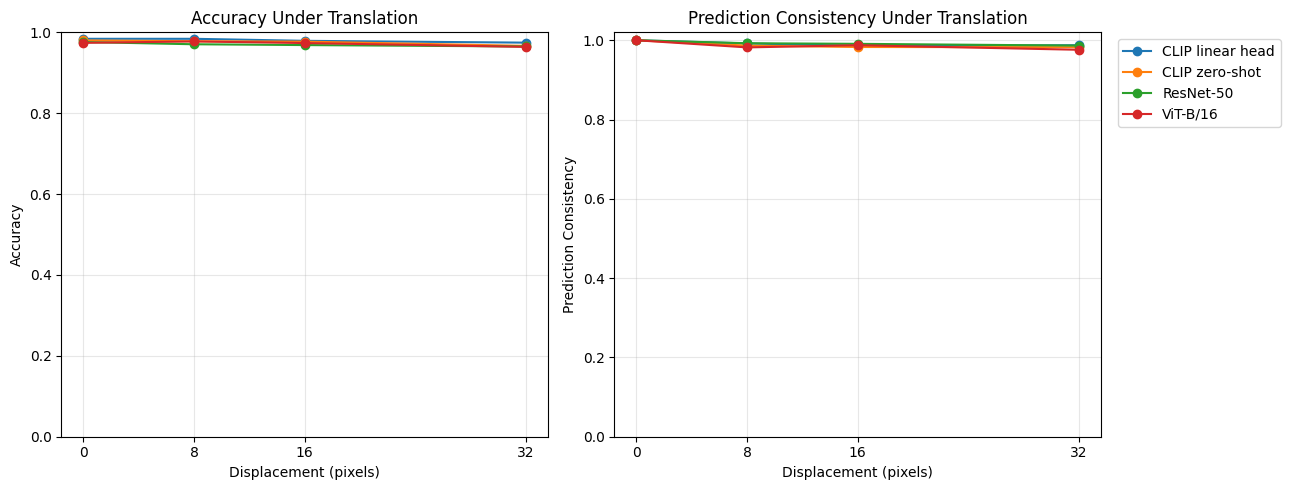

In [31]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

for system_name, group in (
    translation_average_df.groupby("system")
):
    group = group.sort_values(
        "displacement"
    )

    axes[0].plot(
        group["displacement"],
        group["accuracy"],
        marker="o",
        label=system_name,
    )

    axes[1].plot(
        group["displacement"],
        group["prediction_consistency"],
        marker="o",
        label=system_name,
    )

axes[0].set_title(
    "Accuracy Under Translation"
)
axes[0].set_xlabel(
    "Displacement (pixels)"
)
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(
    TRANSLATION_DISPLACEMENTS
)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)

axes[1].set_title(
    "Prediction Consistency Under Translation"
)
axes[1].set_xlabel(
    "Displacement (pixels)"
)
axes[1].set_ylabel(
    "Prediction Consistency"
)
axes[1].set_xticks(
    TRANSLATION_DISPLACEMENTS
)
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)

axes[1].legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "translation_curves.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [32]:
assert len(intervention_results_df) == 16

zero_displacement = translation_average_df[
    translation_average_df["displacement"] == 0
]

assert np.allclose(
    zero_displacement["prediction_consistency"],
    1.0,
)

for model_name in MODEL_NAMES:
    reference_indices = None

    for condition in MAIN_INTERVENTIONS:
        data = torch.load(
            FEATURES_DIR
            / f"{model_name}_{condition}_test.pt",
            map_location="cpu",
            weights_only=False,
        )

        assert len(data["features"]) == 500
        assert torch.isfinite(
            data["features"]
        ).all()

        if reference_indices is None:
            reference_indices = data["indices"]
        else:
            assert torch.equal(
                data["indices"],
                reference_indices,
            )

print("All validation checks passed.")

All validation checks passed.
